# Compare Two Allocation Strategies

Compare **VIX-based rebalance** (QQQ/BIL/GLD with high/low vol bands) vs **long-hold QQQ** over the same period. Each engine receives symbols and date range and fetches data itself. Set `ALPACA_API_KEY` and `ALPACA_API_SECRET` (or rely on Yahoo Finance fallback) and optional cache.

In [1]:
from tiportfolio.helpers.cache import enable_data_source_cache
from tiportfolio import (
    FixRatio,
    Schedule,
    ScheduleBasedEngine,
    VixRegimeAllocation,
    VolatilityBasedEngine,
    compare_strategies,
)

from dotenv import load_dotenv
load_dotenv()

enable_data_source_cache("tiportfolio", cache_dir=".cache")

SYMBOLS = ["QQQ", "BIL", "GLD"]
VOLATILITY_SYMBOL = "VIX"
START = "2018-01-01"
END = "2024-12-31"
INITIAL_VALUE = 10_000
FEE_PER_SHARE = 0.0035

## VIX Target Rebalance

In [2]:
# Strategy 1: VIX-based rebalance — high-vol (0.4, 0.4, 0.2), low-vol (0.7, 0.2, 0.1), target 15, bounds -1 / 5
high_weights = {"QQQ": 0.4, "BIL": 0.4, "GLD": 0.2}
low_weights = {"QQQ": 0.7, "BIL": 0.2, "GLD": 0.1}
allocation_vix = VixRegimeAllocation(
    high_vol_allocation=FixRatio(weights=high_weights),
    low_vol_allocation=FixRatio(weights=low_weights),
)
engine1 = VolatilityBasedEngine(
    allocation=allocation_vix,
    rebalance=Schedule("vix_regime"),
    fee_per_share=FEE_PER_SHARE,
    initial_value=INITIAL_VALUE,
)
result_vix_regime = engine1.run(
    symbols=SYMBOLS,
    start=START,
    end=END,
    volatility_symbol=VOLATILITY_SYMBOL,
    target_vix=15.0,
    lower_bound=-1.0,
    upper_bound=5.0,
)
print(result_vix_regime.summary())

Loaded cached bar data.

Loaded cached bar data.

Backtest Summary
----------------
Sharpe Ratio:    0.8834
CAGR:            15.99%
Max Drawdown:    30.14%
MAR Ratio:       0.5304
Rebalances:      0


In [3]:
from tiportfolio.report import plot_portfolio_with_assets_interactive

fig = plot_portfolio_with_assets_interactive(result_vix_regime, mark_rebalances=True)
fig.show()

In [4]:
from tiportfolio.report import rebalance_decisions_table

decisions_df = rebalance_decisions_table(result_vix_regime)
decisions_df.head(10)

""


## Long Hold QQQ

In [5]:
# Strategy 2: Long hold QQQ (no rebalance)
engine2 = ScheduleBasedEngine(
    allocation=FixRatio(weights={"QQQ": 1.0}),
    rebalance=Schedule("month_start"),
    fee_per_share=FEE_PER_SHARE,
    initial_value=INITIAL_VALUE,
)
result_qqq_only = engine2.run(
    symbols=["QQQ"],
    start=START,
    end=END,
)
print(result_qqq_only.summary())

Loaded cached bar data.



Backtest Summary
----------------
Sharpe Ratio:    0.8518
CAGR:            19.24%
Max Drawdown:    35.01%
MAR Ratio:       0.5495
Rebalances:      0


In [6]:
compare_strategies(
    result_vix_regime,
    result_qqq_only,
    name_a="VIX regime (QQQ/BIL/GLD)",
    name_b="Long QQQ",
)

,VIX regime (QQQ/BIL/GLD),Long QQQ,better
metric,,,
sharpe_ratio,0.883369,0.851775,A
cagr,0.159853,0.192355,B
max_drawdown,0.301358,0.350069,A
mar_ratio,0.530441,0.549477,B


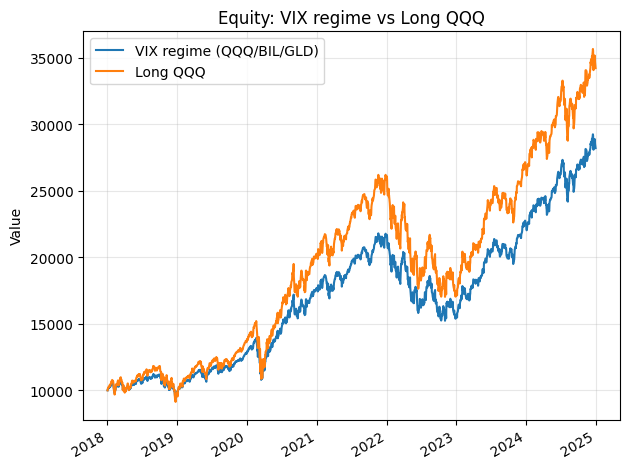

In [7]:
# Optional: overlay equity curves
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
result_vix_regime.equity_curve.plot(ax=ax, label="VIX regime (QQQ/BIL/GLD)")
result_qqq_only.equity_curve.plot(ax=ax, label="Long QQQ")
ax.set_title("Equity: VIX regime vs Long QQQ")
ax.set_ylabel("Value")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()